In [85]:
import numpy as np
import pickle
import os
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Example demonstration of 2D world, belief of the object pose, and robot trajectory in the 2D world.

In [86]:
num_particles = 100
dt=0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


0


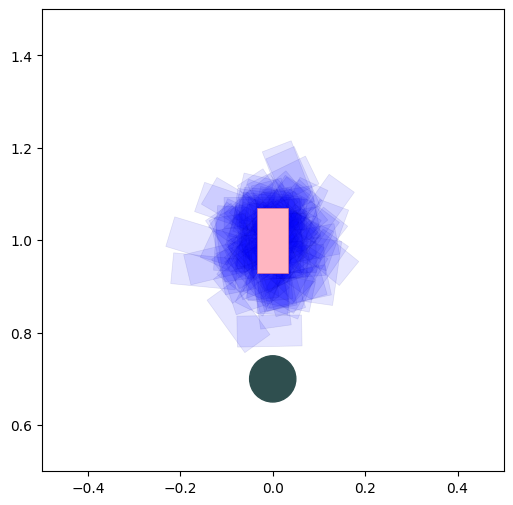

In [87]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

Keeping indices: [27, 47]


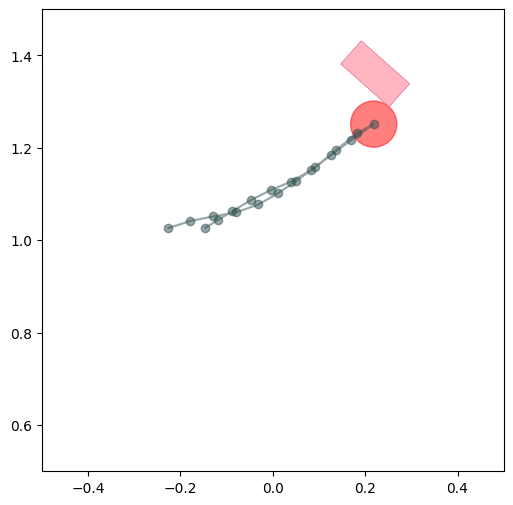

In [91]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements

contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

Differentiable particle filter

In [152]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
proposer_keep_ratio = 0.15
min_obs_likelihood = 0.004

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 10
batch_size = 20
epoch_length = 50
num_epochs = 100
patience = 10
learning_rate = 0.0003
dropout_keep_ratio = 0.3
num_particles = 100
particle_std = 0.2

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, world)

In [153]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/data.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary

In [154]:
# data generation parameters
num_sequences = 200
num_steps_per_sequence = 100

data = organise_data(raw_data, num_sequences, num_steps_per_sequence)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('Observation data:', data['o'].shape)
print('Action data:', data['a'].shape) # note: action was modified so it represents current desired robot position

Object pose data: (200, 1, 3)
Robot pose data: (200, 100, 2)
Observation data: (200, 100, 1)
Action data: (200, 100, 2)


In [155]:
# compute some statistics aboout the data
means, stds, q_o_maxs, q_o_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data)

In [156]:
train_data, val_data = split_data(data, split_ratio)

print('Training data:', train_data['q_r'].shape)
print('Validation data', val_data['q_r'].shape)

Training data: (160, 100, 2)
Validation data (40, 100, 2)


In [157]:
# create dataset and dataloader for training and validation
train_dataset = TrajectoriesDataset(train_data, seq_len)
val_dataset = TrajectoriesDataset(val_data, seq_len)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

# test the dataloader
for batch in train_dataloader:
    print(batch['q_o'].shape)  # Expected shape: [20, 0, 3]
    print(batch['q_r'].shape)  # Expected shape: [20, 10, 2]
    print(batch['o'].shape)    # Expected shape: [20, 10, 1]
    print(batch['a'].shape)    # Expected shape: [20, 10, 2]
    break

torch.Size([20, 1, 3])
torch.Size([20, 10, 2])
torch.Size([20, 10, 1])
torch.Size([20, 10, 2])


In [158]:
# check that models have been built
dpf.build_networks()
print(dpf.obs_like_estimator)
print(dpf.particle_proposer)

ObsLikelihoodEstimator(
  (linear_stack): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=1, bias=True)
    (2): Sigmoid()
  )
)
ParticleProposer(
  (linear_stack): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=16, bias=True)
    (6): ReLU()
    (7): Linear(in_features=16, out_features=3, bias=True)
    (8): Sigmoid()
  )
)


In [159]:
iterator = iter(train_dataloader)
batch = next(iterator)

a_batch = batch['a'][:, 0, :]
q_r_batch = batch['q_r'][:, 0, :]
o_batch = batch['o'][:, 0, :]
                    
# define input to the particle proposer network
input_pp = torch.cat((a_batch, q_r_batch, o_batch), -1)

print(input_pp.shape)

torch.Size([20, 5])


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

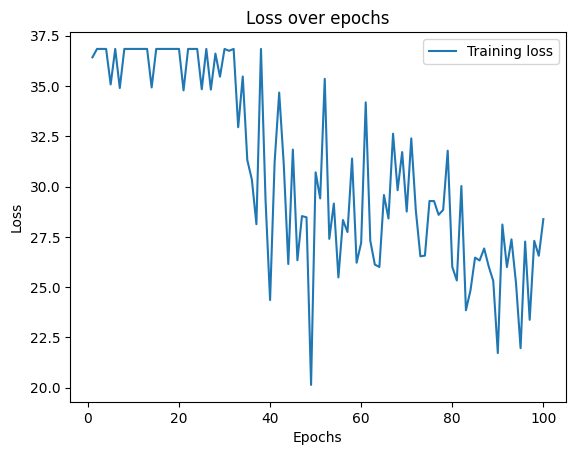

In [160]:
dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs, patience, learning_rate, num_particles)

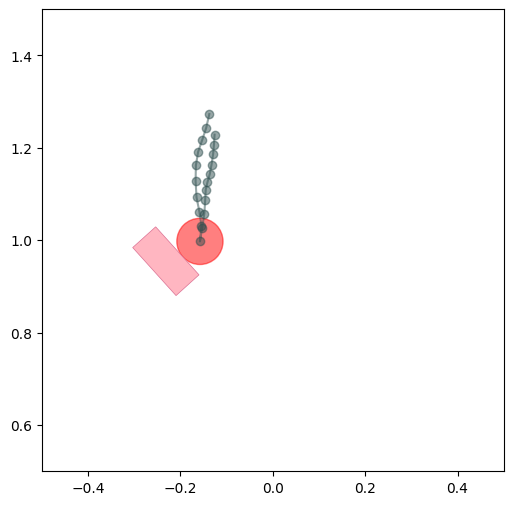

[-0.31619069  1.10556391]
0


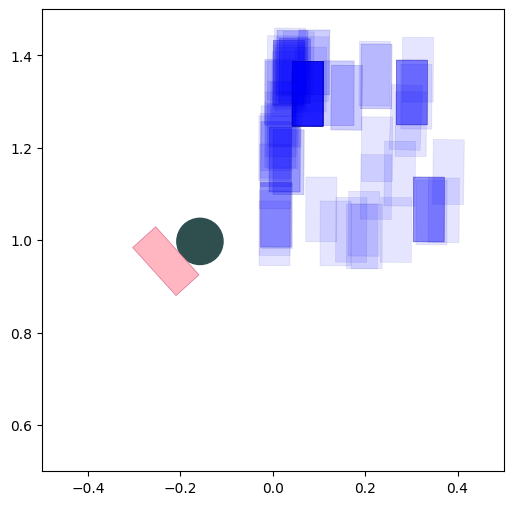

In [190]:
dpf.test(q_o_mins, q_o_maxs)

In [162]:
print(world.q_r_0)

[0.05163865 1.03232408]
